# <font color='Red'>Named Entity Recognition (NER) using LSTM</font>

Named-entity recognition (NER) (also known as entity identification, entity chunking and entity extraction) is a subtask of information extraction that seeks to locate and classify named entities mentioned in unstructured text into pre-defined categories such as person names, organizations, locations, medical codes, time expressions, quantities, monetary values, percentages, etc. I am training LSTM based deep learning model for Recognizing Named Entity.

# <font color='green'>Required Libary Install</font>


In [62]:
# pip install keras==2.13.1
# pip install transformers==4.51.3
# pip install tensorflow==2.13
# !pip install livelossplot

# !pip install tensorflow pandas numpy scikit-learn gensim seqeval


# <font color='blue'>Required Libary Import</font>

This cell imports necessary libraries for data handling, visualization, modeling, and evaluation. sklearn_crfsuite will be used for the baseline CRF model.

In [105]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
np.random.seed(0)
plt.style.use("ggplot")

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from collections import Counter as C
import plotly.express as px
import plotly.io as pio

import tensorflow as tf
print('Tensorflow version:', tf.__version__)
print('GPU detected:', tf.config.list_physical_devices('GPU'))


from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Embedding, Dense
from tensorflow.keras.layers import TimeDistributed, SpatialDropout1D, Bidirectional

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from livelossplot.tf_keras import PlotLossesCallback

from tensorflow.keras.callbacks import TensorBoard
import datetime

Tensorflow version: 2.13.0
GPU detected: []


# <font color='pink'>Load and Explore the NER Dataset </font>


*Essential info about tagged entities*:
- geo = Geographical Entity
- org = Organization
- per = Person
- gpe = Geopolitical Entity
- tim = Time indicator
- art = Artifact
- eve = Event
- nat = Natural Phenomenon

Named Entity Recognition (NER) problem. This will include:

Loading and Preprocessing the Dataset

Train-Validation-Test Split

Data Formatting for Modeling

Baseline Model using CRF (Conditional Random Fields)

Evaluation Metrics

In [106]:
#Loading data
df= pd.read_csv("ner_dataset.csv",encoding="latin1")
df.head()

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,NaN,of,IN,O
2,NaN,demonstrators,NNS,O
3,NaN,have,VBP,O
4,NaN,marched,VBN,O


In [107]:
# df["Sentence #"]

In [108]:
# C(df["Word"])

In [109]:
# C(df["POS"])

In [110]:
# C(df["Tag"])

In [111]:
#Looking for null values
print(df.isnull().sum())

Sentence #    1000616
Word               10
POS                 0
Tag                 0
dtype: int64


In [112]:
def get_missing_value_columns(data, threshold=70.0):
    missing_percent = data.isnull().mean() * 100
    high_missing_cols = missing_percent[missing_percent > threshold].index.tolist()
    return high_missing_cols

In [113]:
missing_values_cols= get_missing_value_columns(data=df, threshold=70)

print("Columns with >70% missing values:", missing_values_cols)
len(missing_values_cols)
print("#"*100)
len(missing_values_cols)

Columns with >70% missing values: ['Sentence #']
####################################################################################################


1

In [114]:
def visualize_missing_columns(data, threshold=70.0):
    high_missing = data.isnull().mean() * 100
    # high_missing = missing_percent[missing_percent > threshold].sort_values(ascending=False)
    if high_missing.empty:
        return
    fig = px.bar(high_missing, x=high_missing.index, y=high_missing.values,
                 labels={"x": "Column Name", "y": "% Missing"},
                 title=f"Columns with > {threshold}% Missing Values")
    fig.update_layout(xaxis_tickangle=-45)
    fig.show()


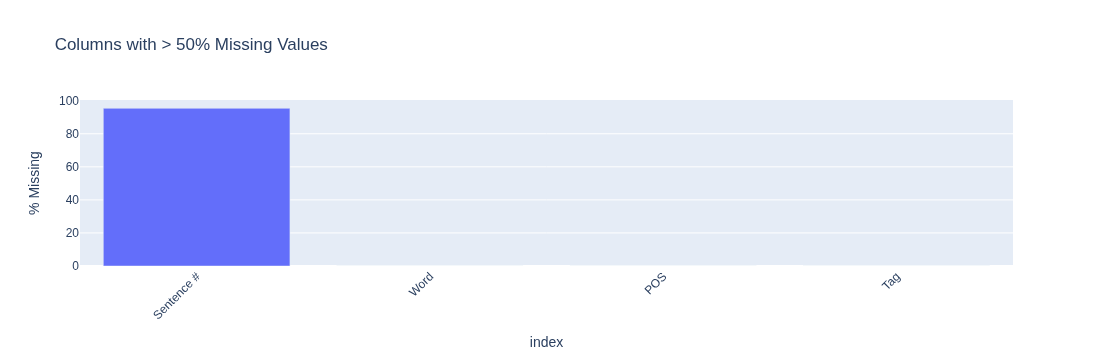

In [115]:
visualize_missing_columns(df, 50)

In [116]:
#Filling Null Values
df = df.fillna(method='ffill')
df.head()

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,Sentence: 1,of,IN,O
2,Sentence: 1,demonstrators,NNS,O
3,Sentence: 1,have,VBP,O
4,Sentence: 1,marched,VBN,O


In [117]:
print("Unique Words in corpus:",df['Word'].nunique())
print("Unique Tag in corpus:",df['Tag'].nunique())

Unique Words in corpus: 35177
Unique Tag in corpus: 17


In [118]:
#Storing unique words and tags as a list
words = list(set(df['Word'].values))
words.append("ENDPAD")
num_words = len(words)
print(num_words)
# words[:100]

35178


In [119]:
tags = list(set(df['Tag'].values))
num_tags = len(tags)

In [120]:
df['Sentence #'][:10], df['Tag'][:10]

(0    Sentence: 1
 1    Sentence: 1
 2    Sentence: 1
 3    Sentence: 1
 4    Sentence: 1
 5    Sentence: 1
 6    Sentence: 1
 7    Sentence: 1
 8    Sentence: 1
 9    Sentence: 1
 Name: Sentence #, dtype: object,
 0        O
 1        O
 2        O
 3        O
 4        O
 5        O
 6    B-geo
 7        O
 8        O
 9        O
 Name: Tag, dtype: object)

In [121]:
unique_words = len(np.unique(df['Word']))
unique_tags = df['Tag'].unique()
total_unique_tags = len(np.unique(df['Tag']))

print("total unique words :", unique_words)
print("total unique tags :", total_unique_tags)
print("tags : ", unique_tags)

total unique words : 35177
total unique tags : 17
tags :  ['O' 'B-geo' 'B-gpe' 'B-per' 'I-geo' 'B-org' 'I-org' 'B-tim' 'B-art'
 'I-art' 'I-per' 'I-gpe' 'I-tim' 'B-nat' 'B-eve' 'I-eve' 'I-nat']



# <font color='pinkblue'> Retrieve Sentences and Corresponsing Tags</font>

Group Words and Tags by Sentences : Groups words and corresponding NER tags into complete sentences for processing by sequence models.



In [122]:
agg_func = lambda s: list(s)
grouped = df.groupby("Sentence #").agg({"Word": agg_func, "Tag": agg_func})
grouped = grouped.reset_index()
grouped.head()


,Sentence #,Word,Tag
0,Sentence: 1,"[Thousands, of, demonstrators, have, marched, ...","[O, O, O, O, O, O, B-geo, O, O, O, O, O, B-geo..."
1,Sentence: 10,"[Iranian, officials, say, they, expect, to, ge...","[B-gpe, O, O, O, O, O, O, O, O, O, O, O, O, O,..."
2,Sentence: 100,"[Helicopter, gunships, Saturday, pounded, mili...","[O, O, B-tim, O, O, O, O, O, B-geo, O, O, O, O..."
3,Sentence: 1000,"[They, left, after, a, tense, hour-long, stand...","[O, O, O, O, O, O, O, O, O, O, O]"
4,Sentence: 10000,"[U.N., relief, coordinator, Jan, Egeland, said...","[B-geo, O, O, B-per, I-per, O, B-tim, O, B-geo..."


In [123]:
#Creating a class to get data in desired formate. i.e. Word,POS,Tag
class SentanceGetter(object):
  def __init__(self,data):
    self.n_sent = 1 #counter
    self.data = data
    agg_func = lambda s:[(w,p,t) for w,p,t in zip(s['Word'].tolist(),s['POS'].tolist(),s['Tag'].tolist())]
    self.grouped = self.data.groupby("Sentence #").apply(agg_func)
    self.sentances = [s for s in self.grouped]

In [124]:
getter = SentanceGetter(data)
sentances = getter.sentances

In [125]:
sentances[0]

[('Thousands', 'NNS', 'O'),
 ('of', 'IN', 'O'),
 ('demonstrators', 'NNS', 'O'),
 ('have', 'VBP', 'O'),
 ('marched', 'VBN', 'O'),
 ('through', 'IN', 'O'),
 ('London', 'NNP', 'B-geo'),
 ('to', 'TO', 'O'),
 ('protest', 'VB', 'O'),
 ('the', 'DT', 'O'),
 ('war', 'NN', 'O'),
 ('in', 'IN', 'O'),
 ('Iraq', 'NNP', 'B-geo'),
 ('and', 'CC', 'O'),
 ('demand', 'VB', 'O'),
 ('the', 'DT', 'O'),
 ('withdrawal', 'NN', 'O'),
 ('of', 'IN', 'O'),
 ('British', 'JJ', 'B-gpe'),
 ('troops', 'NNS', 'O'),
 ('from', 'IN', 'O'),
 ('that', 'DT', 'O'),
 ('country', 'NN', 'O'),
 ('.', '.', 'O')]

# <font color='Red'> Define Mappings between Sentences and Tags</font>


In [126]:
word2idx =  {w : i+1 for i,w in enumerate(words)}
tag2idx  =  {t : i for i,t in enumerate(tags)}

In [127]:
# tag2idx

In [128]:
# word2idx

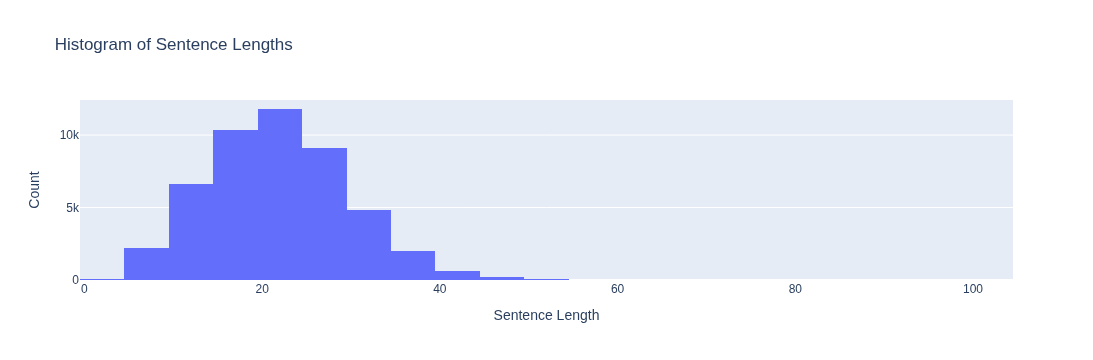

In [129]:
import plotly.graph_objects as go

# Note the corrected variable name here
lengths = [len(s) for s in sentances]

fig = go.Figure(data=[go.Histogram(x=lengths, nbinsx=50)])
fig.update_layout(title='Histogram of Sentence Lengths', xaxis_title='Sentence Length', yaxis_title='Count')
fig.show()



# <font color='Yelloblack'>Feature and Target Selection</font>

In [130]:
max_len = 75

X = [[word2idx[w[0]] for w in s]for s in sentances]
X = pad_sequences(maxlen = max_len , sequences =X, padding='post', value =num_words-1)

y = [[tag2idx[w[2]] for w in s]for s in sentances]
y = pad_sequences(maxlen = max_len , sequences =y, padding='post', value =tag2idx["O"])
y = [to_categorical(i, num_classes=num_tags) for i in y]

# <font color='red'>Train-Test Split</font>
dataset into training and testing subsets. use 90% for training and 10% for testing

In [131]:
x_train,x_test,y_train,y_test = train_test_split(X,y, test_size=0.1, random_state=1)

# <font color='Green'>Build and Compile a Bidirectional LSTM Model</font>
Deep neural network that reduces the high-dimensional feature input into a embedding.

In [132]:
input_word = Input(shape = (max_len,))
model = Embedding(input_dim=num_words,output_dim=max_len,input_length=max_len)(input_word)
model = SpatialDropout1D(0.1)(model)
model = Bidirectional(LSTM(units=100, return_sequences=True, recurrent_dropout=0.1))(model)
out = TimeDistributed(Dense(num_tags,activation='softmax'))(model)
model = Model(input_word,out)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 75)]              0         
                                                                 
 embedding_1 (Embedding)     (None, 75, 75)            2638350   
                                                                 
 spatial_dropout1d (Spatial  (None, 75, 75)            0         
 Dropout1D)                                                      
                                                                 
 bidirectional_1 (Bidirecti  (None, 75, 200)           140800    
 onal)                                                           
                                                                 
 time_distributed_1 (TimeDi  (None, 75, 17)            3417      
 stributed)                                                      
                                                           

In [133]:
model.compile(optimizer="adam",loss='categorical_crossentropy',metrics=['accuracy'])

# <font color='Green'>Train the Model</font>
epochs: The number of times the entire training dataset is passed through the model. You can increase this for better performance but risk overfitting if it's too high.

batch_size: The number of samples processed before the model is updated. A smaller batch size might make training slower, but it can help the model generalize better.

validation_data: The validation data (X_test_scaled and y_test) allows us to monitor the model's performance on unseen data during training.

In [134]:
early_stopping = EarlyStopping(monitor='val_accuracy',patience=1,verbose=0,mode='max',restore_best_weights=False)
# callbacks = [PlotLossesCallback(),early_stopping]

In [135]:


log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

callbacks = [tensorboard_callback, early_stopping]

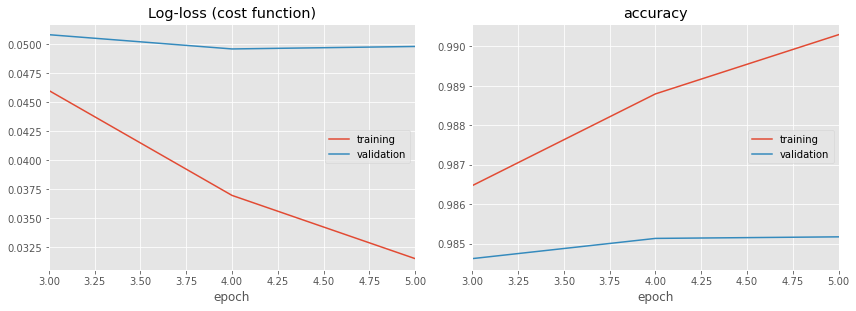

Log-loss (cost function):
training   (min:    0.032, max:    0.268, cur:    0.032)
validation (min:    0.050, max:    0.109, cur:    0.050)

accuracy:
training   (min:    0.944, max:    0.990, cur:    0.990)
validation (min:    0.970, max:    0.985, cur:    0.985)
34530/34530 [==============================] - 115s 3ms/sample - loss: 0.0315 - accuracy: 0.9903 - val_loss: 0.0498 - val_accuracy: 0.9852


In [24]:
early_stopping = EarlyStopping(monitor='val_accuracy',patience=1,verbose=0,mode='max',restore_best_weights=False)
callbacks = [PlotLossesCallback(),early_stopping]

history = model.fit(
    x_train,np.array(y_train),
    validation_split = 0.2,
    batch_size = 64,
    epochs = 5,
    verbose = 1,
    callbacks=callbacks
)

# <font color='red'>Save the Model</font>


In [ ]:
model.save("my_model")  


# <font color='pink'>Evaluate Named Entity Recognition Model</font>


In [25]:
model.evaluate(x_test, np.array(y_test))

4796/4796 [==============================] - 6s 1ms/sample - loss: 0.0508 - accuracy: 0.9850


[0.05077056285985019, 0.98502505]

In [30]:
i = np.random.randint(0, x_test.shape[0])
p = model.predict(np.array([x_test[i]]))
p = np.argmax(p, axis=-1)

y_true = np.argmax(np.array(y_test), axis=-1)[i]
print("{:15}{:5}\t {}\n".format("Word","True","Pred"))
print("-"*30)
for w,true,pred in zip(x_test[i], y_true, p[0]):
  print("{:15}{:5}\t{}".format(words[w-1], tags[true],tags[pred]))

Word           True 	 Pred

------------------------------
The            B-org	O
Associated     I-org	I-org
Press          I-org	I-org
says           O    	O
the            O    	O
recommendation O    	O
by             O    	O
Colonel        O    	O
James          B-per	B-per
Daniel         I-per	I-per
will           O    	O
be             O    	O
forwarded      O    	O
to             O    	O
Army           B-org	B-org
officials      O    	O
for            O    	O
a              O    	O
final          O    	O
decision       O    	O
.              O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
communication  O    	O
c